# ***Importing Libraries***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier,GradientBoostingClassifier,AdaBoostClassifier,VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score,recall_score,f1_score,roc_auc_score,roc_curve,auc
import warnings
warnings.filterwarnings('ignore')

# ***Exploratory Data Analysis (EDA)***

In [ ]:
df = pd.read_csv('Customer Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe(include=["number"]).T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [ ]:
df.describe(include=["object"])

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.drop("customerID", axis = 1, inplace = True)

In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
num_df = df.select_dtypes(include=["number"])
cat_df = df.select_dtypes(include=["object"])

# *Data Visiualization*




<Axes: >

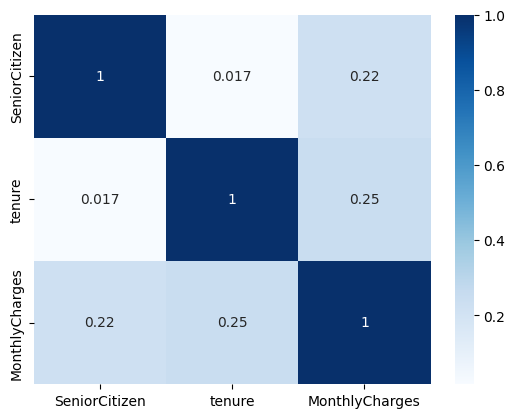

In [ ]:
sns.heatmap(num_df.corr(),annot=True,cmap="Blues")

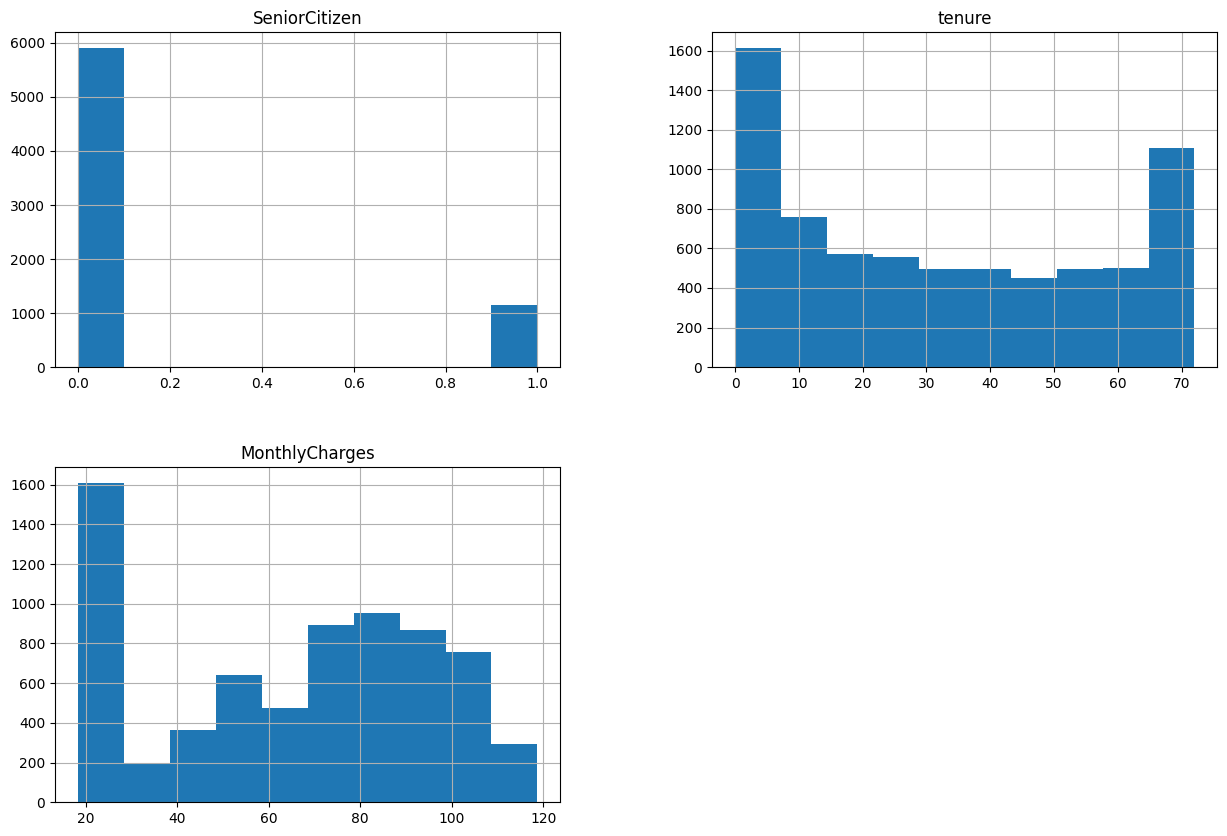

In [ ]:
num_df.hist(figsize=(15,10));

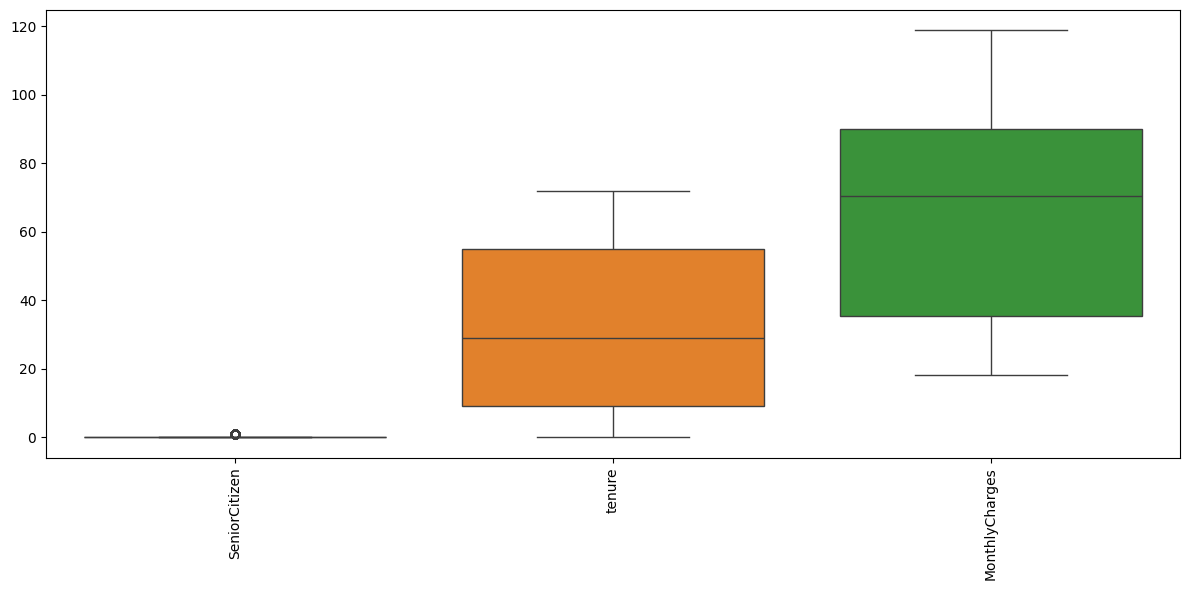

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=num_df)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

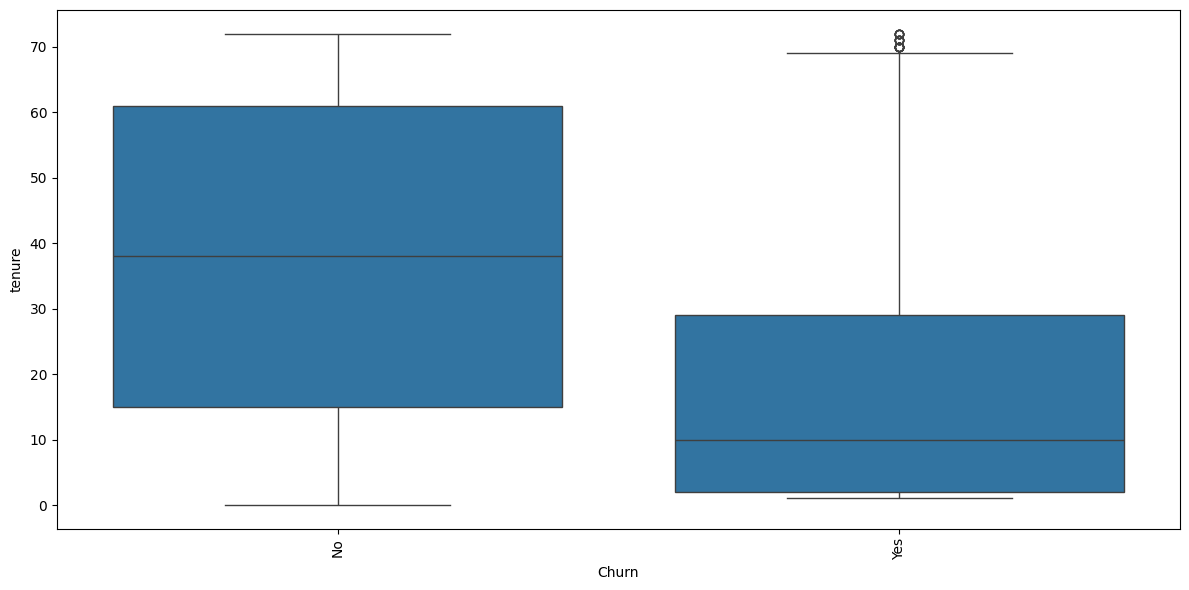

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df,x="Churn",y="tenure")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

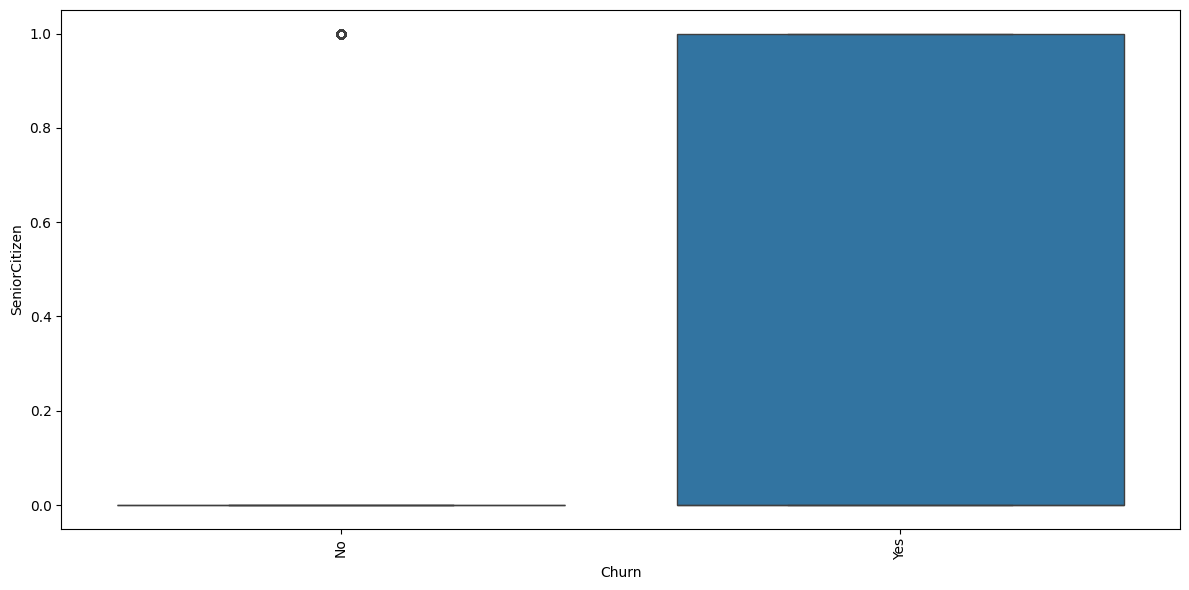

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df,x="Churn",y='SeniorCitizen')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

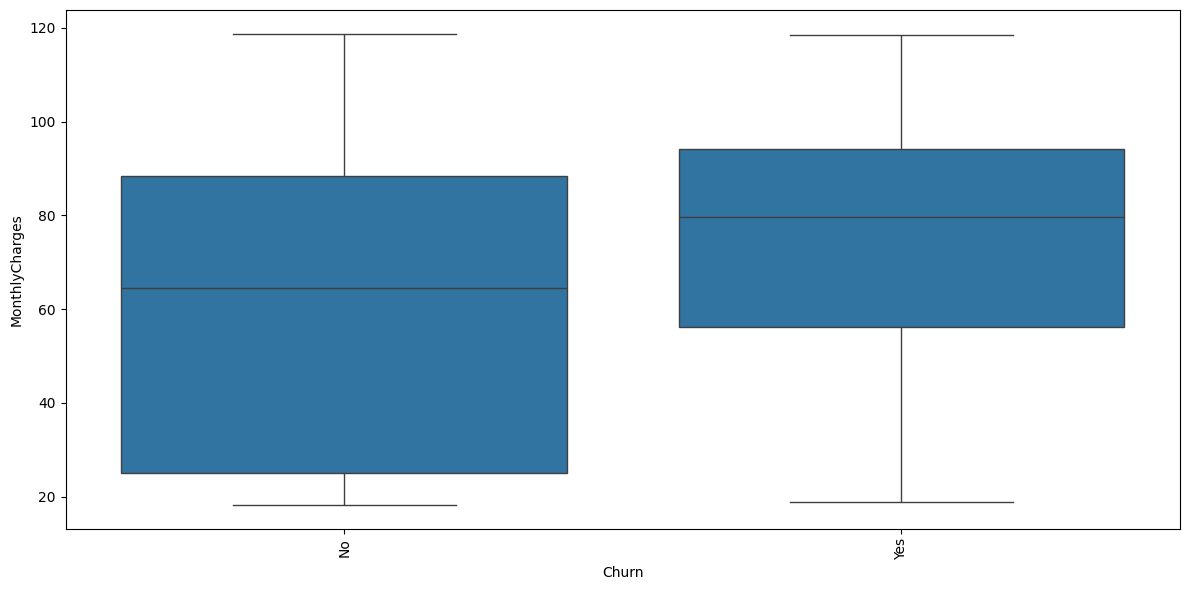

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df,x="Churn",y='MonthlyCharges')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

<Axes: xlabel='gender', ylabel='count'>

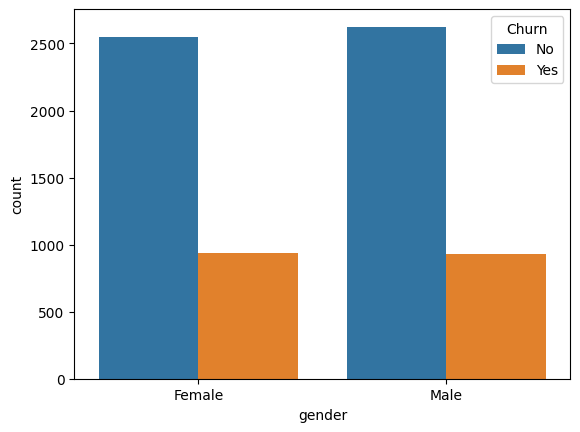

In [ ]:
sns.countplot(data= df,x=cat_df['gender'],hue="Churn")

<Axes: xlabel='PhoneService', ylabel='count'>

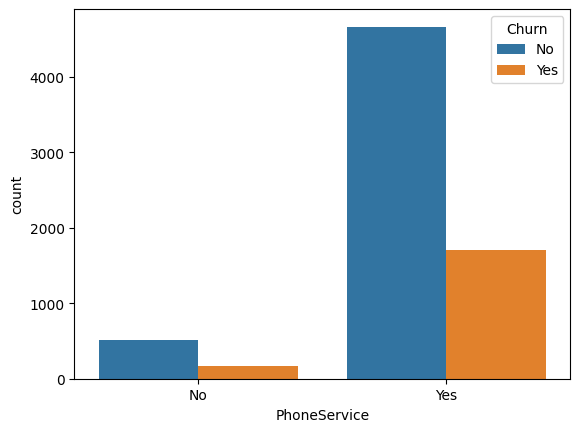

In [ ]:
sns.countplot(data= df,x=cat_df['PhoneService'],hue="Churn")

<Axes: xlabel='OnlineSecurity', ylabel='count'>

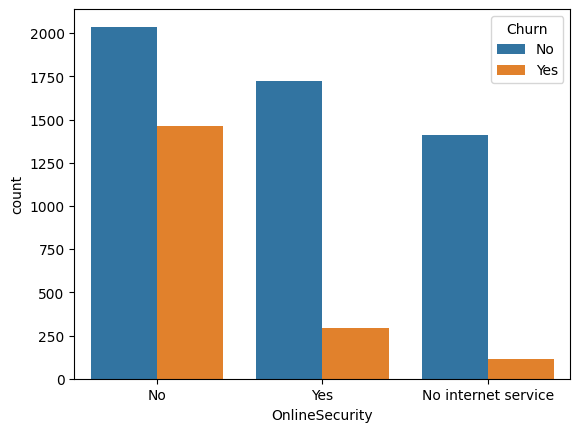

In [ ]:
sns.countplot(data= df,x=cat_df['OnlineSecurity'],hue="Churn")

<Axes: xlabel='InternetService', ylabel='count'>

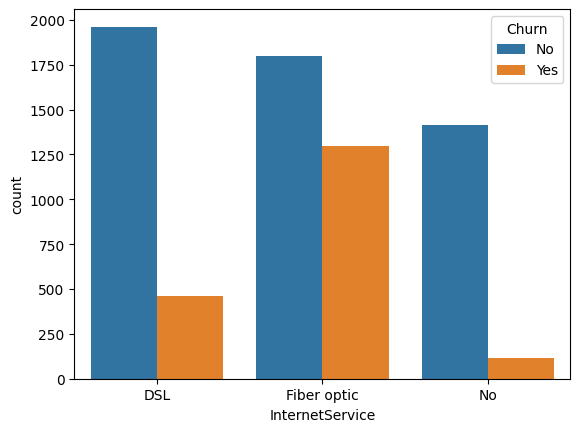

In [ ]:
sns.countplot(data= df,x=cat_df['InternetService'],hue="Churn")

<Axes: xlabel='TechSupport', ylabel='count'>

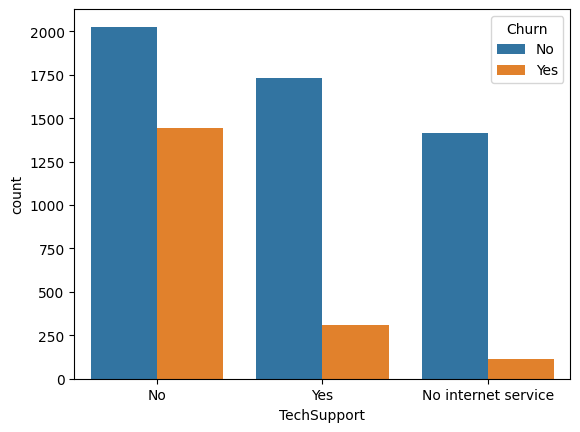

In [ ]:
sns.countplot(data= df,x=cat_df['TechSupport'],hue="Churn")

# ***Data Preprocessing***

In [ ]:
for col in num_df:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

In [ ]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

In [ ]:
for col in cat_df:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('Churn',axis=1)
y = df['Churn']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, stratify=y,random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
models = {
    "LogisticRegression": (LogisticRegression(class_weight='balanced'), {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs'], 'max_iter':[1000]}),
    "KNeighborsClassifier": (KNeighborsClassifier(), {'n_neighbors':[3,5,7,9], 'weights':['uniform','distance'], 'metric':['euclidean','manhattan']}),
    "SVC": (SVC(probability=True,class_weight='balanced'), {'C':[0.1,1,10],'kernel':['linear','rbf','poly'],'gamma':['scale','auto']}),
    "DecisionTreeClassifier": (DecisionTreeClassifier(class_weight='balanced'), {'max_depth':[None,5,10,20],'min_samples_split':[2,5,10]}),
    "RandomForestClassifier": (RandomForestClassifier(class_weight='balanced'), {'n_estimators':[50,100,200],'max_depth':[None,5,10],'min_samples_split':[2,5,10]}),
    "BaggingClassifier": (BaggingClassifier(), {'n_estimators':[10,50,100]}),
    "GradientBoostingClassifier": (GradientBoostingClassifier(), {'n_estimators':[100,200],'learning_rate':[0.01,0.1,0.2],'max_depth':[3,5]}),
    "AdaBoostClassifier": (AdaBoostClassifier(), {'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,1]}),
    "XGBClassifier": (XGBClassifier(use_label_encoder=False, eval_metric='logloss'), {'n_estimators':[100,200],'max_depth':[3,5,7],'learning_rate':[0.01,0.1,0.2],'scale_pos_weight':[1,5,10]}),
    "GaussianNB": (GaussianNB(), {})
}


In [ ]:
results = []

for name, (model, params) in models.items():
    if params:
        grid = GridSearchCV(model, params, cv=5, scoring='accuracy', n_jobs=-1)
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
    else:
        best_model = model
        best_model.fit(X_train, y_train)
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    y_test_proba = best_model.predict_proba(X_test)[:,1] if hasattr(best_model,'predict_proba') else np.zeros_like(y_test)
    results.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred, zero_division=0),
        'Recall': recall_score(y_test, y_test_pred, zero_division=0),
        'F1': f1_score(y_test, y_test_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, y_test_proba),
        'Confusion Matrix': confusion_matrix(y_test, y_test_pred)
    })


In [ ]:
df_results = pd.DataFrame(results).sort_values(by='Recall', ascending=False)
df_results.reset_index(drop=True, inplace=True)
df_results

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1,ROC_AUC,Confusion Matrix
0,LogisticRegression,0.746361,0.738822,0.505155,0.786096,0.615063,0.836821,"[[747, 288], [80, 294]]"
1,SVC,0.779730,0.739532,0.506130,0.772727,0.611640,0.815203,"[[753, 282], [85, 289]]"
2,GaussianNB,0.758253,0.744500,0.513208,0.727273,0.601770,0.818512,"[[777, 258], [102, 272]]"
3,DecisionTreeClassifier,0.779198,0.762243,0.539877,0.705882,0.611819,0.819286,"[[810, 225], [110, 264]]"
4,RandomForestClassifier,0.971246,0.777857,0.582210,0.577540,0.579866,0.824028,"[[880, 155], [158, 216]]"
5,AdaBoostClassifier,0.805999,0.794890,0.637540,0.526738,0.576867,0.844730,"[[923, 112], [177, 197]]"
6,KNeighborsClassifier,0.816294,0.760823,0.552113,0.524064,0.537723,0.796943,"[[876, 159], [178, 196]]"
7,GradientBoostingClassifier,0.827831,0.799148,0.661922,0.497326,0.567939,0.840286,"[[940, 95], [188, 186]]"
8,XGBClassifier,0.820909,0.795600,0.650350,0.497326,0.563636,0.841825,"[[935, 100], [188, 186]]"
9,BaggingClassifier,0.997160,0.775727,0.596026,0.481283,0.532544,0.807850,"[[913, 122], [194, 180]]"
